In [ ]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from pydantic import BaseModel,Field
import os
import operator

In [35]:
load_dotenv()
token=os.getenv('Hugging_Face_Token')
print(token is not None)

True


In [36]:
llm=HuggingFaceEndpoint(
     repo_id="Qwen/Qwen3-8B",
        task="text-generation",
        max_new_tokens=512,
        temperature=0.7,
        huggingfacehub_api_token=token,
)
model=ChatHuggingFace(llm=llm)

In [37]:
class EvaluationScheme(BaseModel):
    Feedback:str=Field(description="Feedback on the given essay")
    score:int=Field(description="score out of 10")

In [38]:
structured_output = model.with_structured_output(
    EvaluationScheme,
    method="json_schema"
)

In [39]:
class UPSCESSAY(TypedDict):
    essay:str
    language_Feedback:str
    analysis_Feedback:str
    clarity_Feedback:str
    overall_Feedback:str
    individual_scores=Annotated[list[int],operator.add]
    avg_score:int

In [40]:
def Language(state:UPSCESSAY):
   prompt=f"""
       Evaluate the candidate's response and provide overall feedback based on the following three criteria:
   
   1. Language: Evaluate grammar, vocabulary, sentence structure, professionalism, and how naturally the ideas are expressed.
   
   Provide:
   - A brief overall assessment
   - Strengths
   - Areas for improvement
   - Specific suggestions to improve the response
   
   Keep the feedback constructive, concise, and actionable.
   
   Candidate's response:
   {state['essay']}
   
   
   """
   answer=structured_output.invoke(prompt)
   return {
            'language_Feedback':answer.Feedback,
            'individual_score':[answer.score]
    
        }
    
       

In [41]:
def Clarity(state:UPSCESSAY):
   prompt=f"""
       Evaluate the candidate's response and provide overall feedback based on the following three criteria:
   
  
   1. Clarity: Evaluate how clearly and concisely the ideas are communicated and whether the response is easy to understand.
   
   Provide:
   - A brief overall assessment
   - Strengths
   - Areas for improvement
   - Specific suggestions to improve the response
   
   Keep the feedback constructive, concise, and actionable.
   
   Candidate's response:
   {state['essay']}
   
   
   """
   answer=structured_output.invoke(prompt)
   return {
            'clarity_Feedback':answer.Feedback,
            'individual_score':[answer.score]
    
        }
    
       

In [42]:
def Analysis(state:UPSCESSAY):
 prompt=f"""
    Evaluate the candidate's response and provide overall feedback based on the following three criteria:

1. Language: Evaluate grammar, vocabulary, sentence structure, professionalism, and how naturally the ideas are expressed.
2. Analysis: Evaluate the depth of reasoning, logical thinking, relevance of the points, and how well the response addresses the question.
3. Clarity: Evaluate how clearly and concisely the ideas are communicated and whether the response is easy to understand.

Provide:
- A brief overall assessment
- Strengths
- Areas for improvement
- Specific suggestions to improve the response

Keep the feedback constructive, concise, and actionable.

Candidate's response:
{state['essay']}


"""

 answer=structured_output.invoke(prompt)
 return {
         'analysis_Feedback':answer.Feedback,
         'individual_score':[answer.score]
 
     }
 
    

In [43]:
def Overall(state:UPSCESSAY):

    prompt=f"""Based on the feedback provided for language, clarity, and analysis, generate a concise overall feedback summary. Highlight the candidate's main strengths and key areas for improvement without repeating every individual point. Keep the summary constructive, professional, and actionable.

Language Feedback:
{state['language_Feedback']}

Clarity Feedback:
{state['clarity_Feedback']}

Analysis Feedback:
{state['analysis_Feedback']}"""


    answer=structured_output.invoke(prompt)
    return{

        'overall_Feedback':answer.Feedback,
        'individual_score':[answer.score]
    }

    
   

    


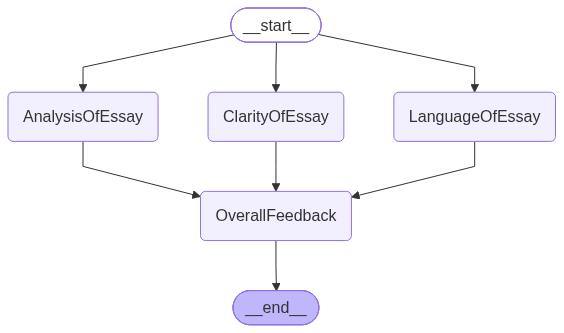

In [44]:
graph=StateGraph(UPSCESSAY)
graph.add_node('ClarityOfEssay',Clarity)
graph.add_node('LanguageOfEssay',Language)
graph.add_node('AnalysisOfEssay',Analysis)
graph.add_node('OverallFeedback',Overall)

graph.add_edge(START,'ClarityOfEssay')
graph.add_edge(START,'LanguageOfEssay')
graph.add_edge(START,'AnalysisOfEssay')
graph.add_edge('ClarityOfEssay','OverallFeedback')
graph.add_edge('AnalysisOfEssay','OverallFeedback')
graph.add_edge('LanguageOfEssay','OverallFeedback')
graph.add_edge('OverallFeedback',END)
graph.compile()


In [46]:
workflow=graph.compile()
essay="""### Topic: The Impact of Artificial Intelligence on Education

Artificial Intelligence (AI) is rapidly changing the way education is delivered and experienced. From personalized learning platforms to AI-powered tutors, technology is helping students learn at their own pace and providing teachers with tools to better understand their students' needs. However, while AI offers many benefits, it also creates challenges that need to be considered carefully.

One of the biggest advantages of AI in education is personalized learning. Traditional classrooms often use the same teaching method for every student, even though students have different learning speeds and abilities. AI systems can analyze a student's performance and identify areas where they are struggling. They can then recommend suitable exercises, explanations, or learning materials. This can help students improve their understanding without feeling pressured to keep up with the entire class.

AI can also reduce the workload of teachers. Tasks such as grading objective assessments, preparing questions, analyzing student performance, and organizing learning materials can be partially automated. This allows teachers to spend more time interacting with students and focusing on activities that require human judgment, creativity, and emotional understanding.

However, excessive dependence on AI can create problems. Students may begin using AI tools to complete assignments without actually understanding the concepts. This can reduce critical thinking and problem-solving abilities. There are also concerns regarding privacy, since AI-based educational platforms may collect large amounts of information about students.

Another important issue is the digital divide. Not every student has access to a reliable internet connection, modern devices, or advanced educational tools. If AI becomes a major part of education without addressing these inequalities, the gap between students with access to technology and those without it could become even larger.

In conclusion, AI has the potential to make education more personalized, efficient, and accessible. However, it should be treated as a tool that supports teachers and students rather than replacing human interaction and independent thinking. The most effective educational system will likely be one where AI handles repetitive and analytical tasks while teachers continue to provide guidance, motivation, creativity, and emotional support.
"""


